In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import MultiPolygon, Polygon

df = gpd.read_file("C:/Users/josem/Downloads/P_Data_Extract_From_World_Development_Indicators (2)/0dcadbc7-bd26-4ddd-9cac-4190ed12a6a0_Data.csv")
df.head()

,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Albania,ALB,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,1.24636024189216,1.30929137475594,1.32003449433204,1.33684292419802,1.38115794211088,1.35000497056322,...,1.16230386432234,1.10358100880452,1.10915100558884,1.16054478505068,1.28080596201472,1.29583570269739,1.24298808396067,1.21098343566728,1.74399167669186,..
1,Albania,ALB,Military expenditure (% of general government ...,MS.MIL.XPND.ZS,3.84384065661926,4.14741288966839,4.26975280105134,4.61292952593064,4.66321103763279,4.73437520175261,...,3.77889251316413,3.78723434007733,3.80346444991409,3.99130087621609,4.40511619586606,3.98075632132468,3.86998513866664,3.97041542821594,5.61952875583332,..
2,Albania,ALB,Armed forces personnel (% of total labor force),MS.MIL.TOTL.TF.ZS,5.13717005098356,3.11413417074067,2.07007907702074,1.70479333642779,1.68531487168875,1.78613955703739,...,0.656344301232692,0.633524160748185,0.660195770052346,0.645800146381367,0.565041583529038,0.591541401612986,..,..,..,..
3,Austria,AUT,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,0.98031858008593,0.908240040709509,0.88352783657309,0.913640318789259,0.893480466242935,0.850142574026263,...,0.698116413133988,0.729737691793485,0.757279033702098,0.745028039648345,0.75035965749035,0.884127145088915,0.8736941368808,0.768528566154672,0.844274840737983,..
4,Austria,AUT,Military expenditure (% of general government ...,MS.MIL.XPND.ZS,1.93159028105101,1.76504348593881,1.68193442016185,1.82318437443309,1.65790767717745,1.66192198199585,...,1.36811785600437,1.45739672398483,1.53610008182722,1.52801954740725,1.54167679725207,1.5570304159137,1.55865661676857,1.45560179338752,1.63257715135905,..


In [17]:


mil_exp = df[df["Series Code"] == "MS.MIL.XPND.GD.ZS"][["Country Name", "Country Code", "2020 [YR2020]"]].copy()
mil_exp = mil_exp.rename(columns={"2020 [YR2020]": "military_exp_2020"})
mil_exp["military_exp_2020"] = pd.to_numeric(mil_exp["military_exp_2020"], errors="coerce")


EastEur = mil_exp



In [18]:
# Load Natural Earth map

world = gpd.read_file("C:/Users/josem/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")


In [19]:
# Clean up geometries

def fix_geom(geom):
    if isinstance(geom, MultiPolygon):
        # take the polygon with the largest area
        largest = max(geom.geoms, key=lambda part: part.area)
        return largest
    return geom

world["geometry"] = world["geometry"].apply(fix_geom)

In [20]:
# --- Merge with expenditure data 

world = world.merge(EastEur,
                    left_on="ADM0_A3",  # this depends on the Natural Earth GeoJSON field for ISO-A3
                    right_on="Country Code",
                    how="left")




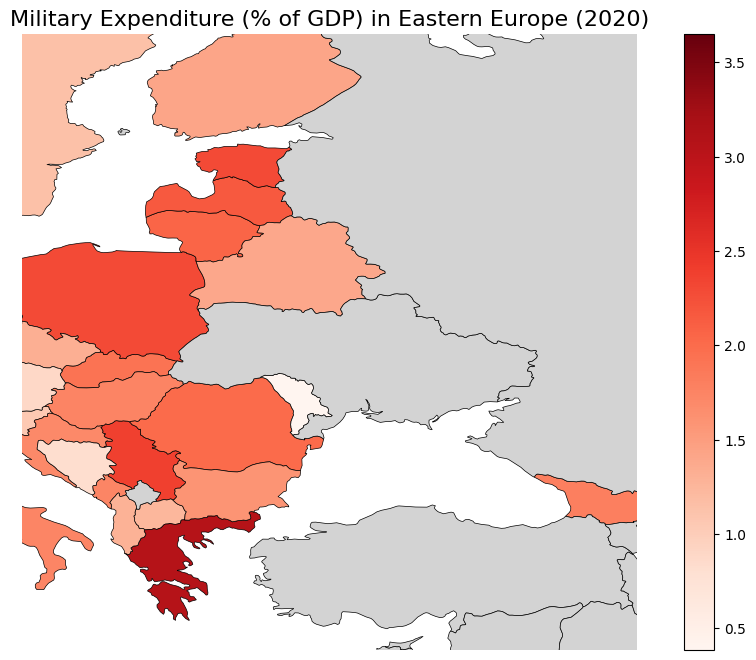

In [21]:
# plot

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
world.plot(
    column="military_exp_2020",
    cmap="Reds",
    linewidth=0.5,
    ax=ax,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title("Military Expenditure (% of GDP) in Eastern Europe (2020)", fontsize=16)
ax.set_xlim([15, 45])   # longitude range
ax.set_ylim([35, 65])   # latitude range
ax.axis("off")

plt.show()

In [46]:
West = mil_exp
#West = West.drop(index=146) # USA
#West


In [47]:
world = world.merge(West,
                    left_on="ADM0_A3",  
                    right_on="Country Code",
                    how="left")

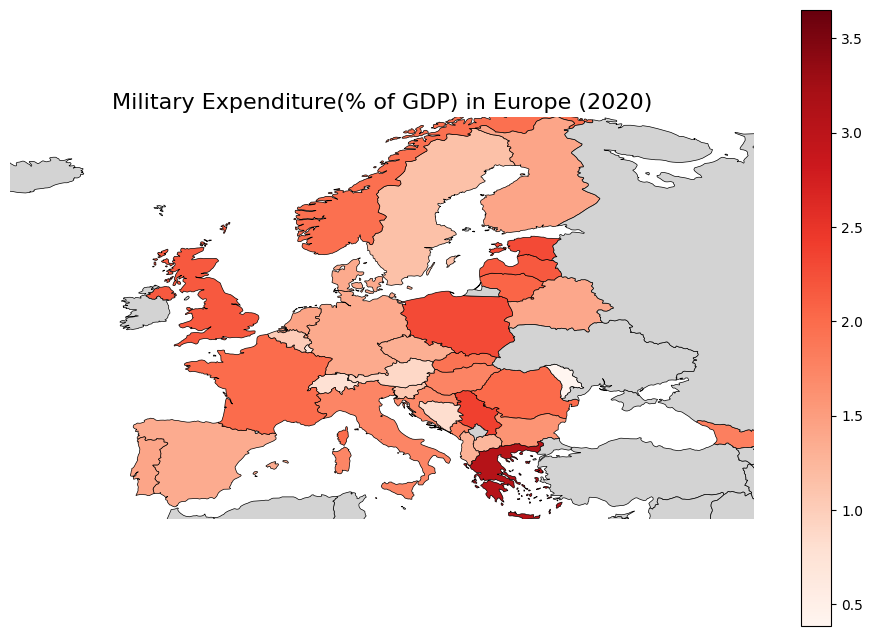

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
world.plot(
    column="military_exp_2020",
    cmap="Reds",
    linewidth=0.5,
    ax=ax,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title("Military Expenditure(% of GDP) in Europe (2020)", fontsize=16)
ax.set_xlim([-20, 45])   # longitude (Portugal → Russia)
ax.set_ylim([35, 70])    # latitude (Mediterranean → Scandanavia)
ax.axis("off")

plt.show()

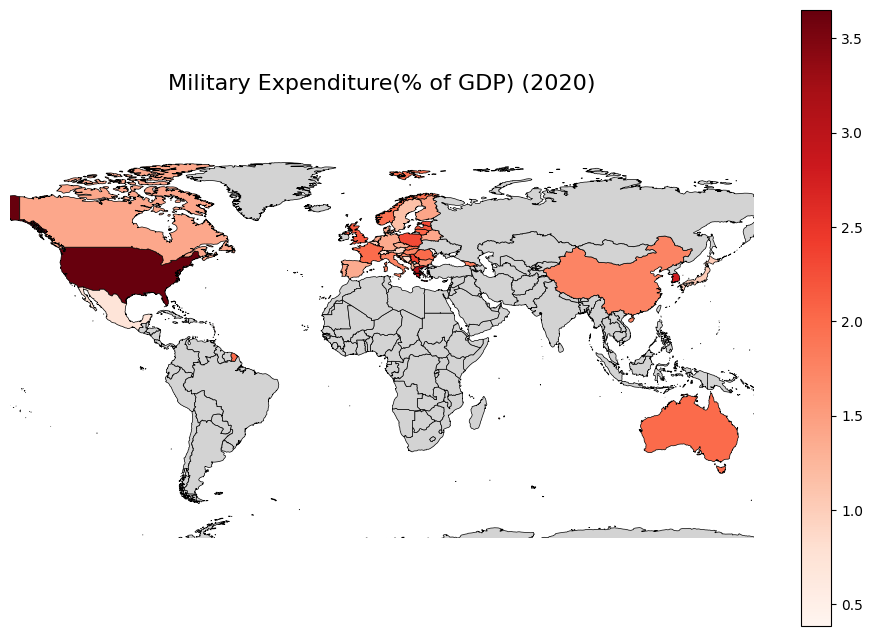

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
world.plot(
    column="military_exp_2020",
    cmap="Reds",
    linewidth=0.5,
    ax=ax,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title("Military Expenditure(% of GDP) (2020)", fontsize=16)
ax.set_xlim([-145, 160])   
ax.set_ylim([-70, 110])    
ax.axis("off")

plt.show()

In [52]:
#mil_exp

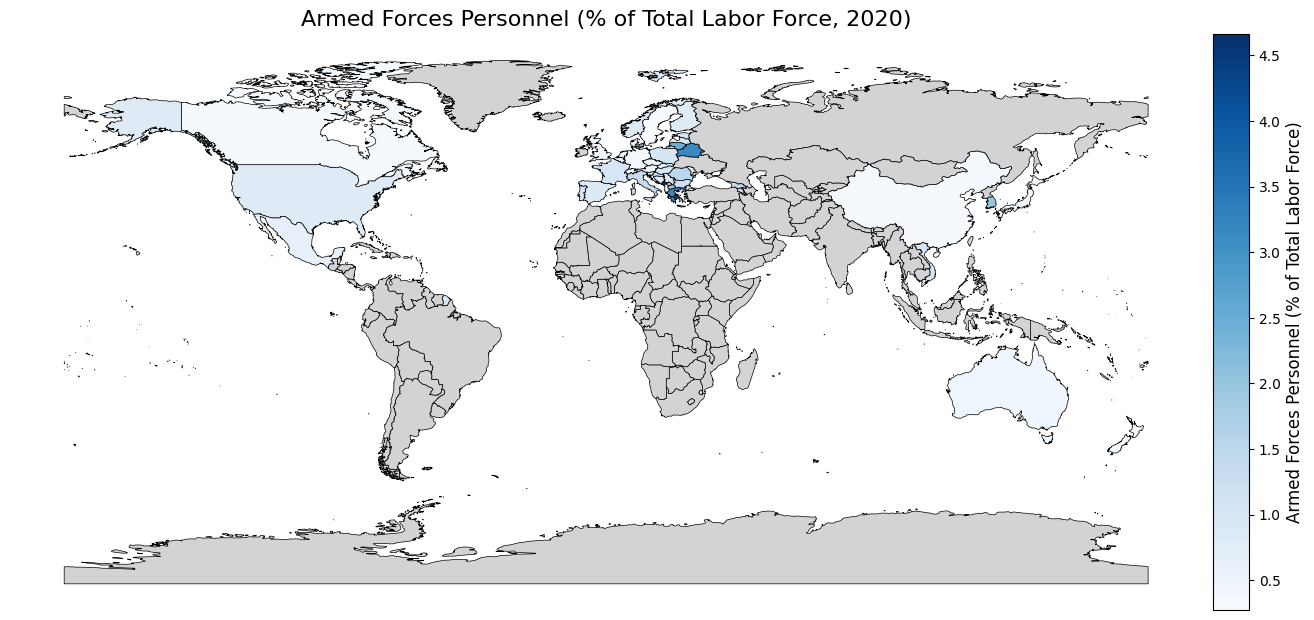

In [58]:


# Load shapefile and dataset
world = gpd.read_file("C:/Users/josem/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
mil_data = pd.read_csv("C:/Users/josem/Downloads/P_Data_Extract_From_World_Development_Indicators (2)/0dcadbc7-bd26-4ddd-9cac-4190ed12a6a0_Data.csv")

# Filter for 2020 military personnel (% of total labor force)
personnel = mil_data[mil_data["Series Name"] == "Armed forces personnel (% of total labor force)"]
personnel_2020 = personnel[["Country Name", "Country Code", "2020 [YR2020]"]].rename(
    columns={"2020 [YR2020]": "military_personnel_2020"}
)

# Convert values to numeric (fixes TypeError)
personnel_2020["military_personnel_2020"] = pd.to_numeric(
    personnel_2020["military_personnel_2020"], errors="coerce"
)

# Merge with world map
world = world.merge(personnel_2020, left_on="ADM0_A3", right_on="Country Code", how="left")

# plot map
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

world_plot = world.plot(
    column="military_personnel_2020",
    cmap="Blues",
    linewidth=0.5,
    ax=ax,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title("Armed Forces Personnel (% of Total Labor Force, 2020)", fontsize=16)
ax.axis("off")

#Add colorbar manually
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

sm = plt.cm.ScalarMappable(
    cmap="Blues",
    norm=plt.Normalize(
        vmin=world["military_personnel_2020"].min(),
        vmax=world["military_personnel_2020"].max()
    )
)
sm._A = []
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Armed Forces Personnel (% of Total Labor Force)", fontsize=12)

plt.show()
